In [1]:
import pickle

path = "/home/ftk3187/github/DPC_research/02_DED/5_policy_1223/loss_history/policy_parameters_3L_1024H_s1_c1_case_0B.pkl"

with open(path, "rb") as f:
    data = pickle.load(f)

print(type(data))

for k, v in data.items():
    print(f"{k}: {v}")


<class 'dict'>
model_name: 3L_1024H_s1_c1
past_input_dim: 6
future_input_dim: 6
output_dim: 1
future_cov_dim: 2
static_cov_dim: 0
window: 50
p: 50
hidden_dim: 1024
n_layers: 3
learning_rate: 0.001
weight_decay: 1e-05
num_epoch: 50
w_smooth: 1
w_constraint: 1


In [2]:
import torch

path = "/home/ftk3187/github/DPC_research/02_DED/5_policy_1223/trainresults/0(BASE)/policy_model_3L_1024H_s1_c1_case_0B.pth"

obj = torch.load(path, map_location="cpu")
type(obj)
obj.keys()

/tmp/ipykernel_806489/747814672.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(path, map_location="cpu")


odict_keys(['input_layer.weight', 'input_layer.bias', 'input_ln.weight', 'input_ln.bias', 'hidden_layers.0.weight', 'hidden_layers.0.bias', 'norm_layers.0.weight', 'norm_layers.0.bias', 'output_layer.weight', 'output_layer.bias'])

# CASE3 | Shift random, |x|<0.1

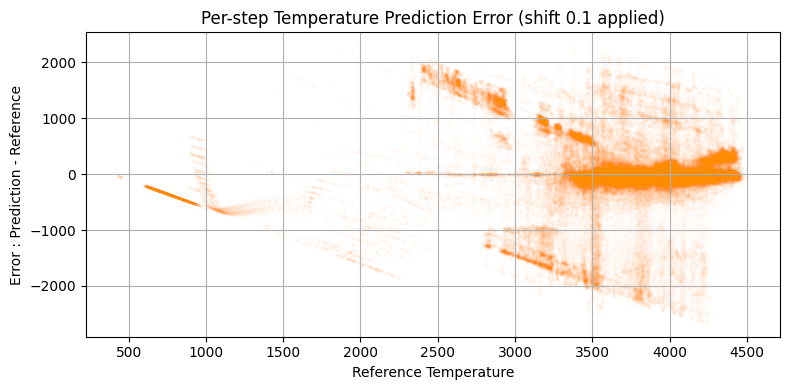

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Directory of saved outputs ───────────────────────
load_dir = "/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case3_onlyshift"
laser_numbers = list(range(2, 50))

# ── 저장용 리스트 ──────────────────────────────────────
ref_temp_all = []
abs_error_all = []

for laser_num in laser_numbers:
    try:
        # Load files
        ref_path = os.path.join(load_dir, f"ref_laser_{laser_num}.csv")
        x_path   = os.path.join(load_dir, f"x_outputs_laser_{laser_num}.csv")

        ref_df = pd.read_csv(ref_path)
        x_df = pd.read_csv(x_path)

        # Extract first column (melt pool temperature)
        ref_temp = ref_df.iloc[:, 0].values
        pred_temp = x_df.iloc[:, 0].values

        # Trim to same length
        min_len = min(len(ref_temp), len(pred_temp))
        ref_temp = ref_temp[:min_len]
        pred_temp = pred_temp[:min_len]

        # Compute absolute error or squared error
        abs_error = (pred_temp - ref_temp)

        # Accumulate for all lasers
        ref_temp_all.append(ref_temp)
        abs_error_all.append(abs_error)

    except Exception as e:
        pass #print(f"❌ Error processing laser {laser_num}: {e}")

# ── Concatenate all points ────────────────────────────
ref_temp_all = np.concatenate(ref_temp_all)
abs_error_all = np.concatenate(abs_error_all)

# ── Scatter plot ──────────────────────────────────────
plt.figure(figsize=(8,4))
plt.scatter(ref_temp_all, abs_error_all, s=0.001, alpha=0.5, color='darkorange')
plt.xlabel("Reference Temperature")
plt.ylabel("Error : Prediction - Reference")
plt.title("Per-step Temperature Prediction Error (shift 0.1 applied)")
plt.grid(True)
plt.tight_layout()
plt.show()


# CASE B0 | Baseline

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

def plot_saved_outputs(save_dir, laser_num, N_step=None):
    # Load data
    x_path = os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv")
    u_path = os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv")
    ref_path = os.path.join(save_dir, f"ref_laser_{laser_num}.csv")

    try:
        x = pd.read_csv(x_path).values
        u = pd.read_csv(u_path).values
        ref = pd.read_csv(ref_path).values.flatten()

        if N_step is None:
            N_step = min(len(x), len(u), len(ref))

        plt.figure(figsize=[8, 6])
        plt.suptitle(f"Laser Power Number: {laser_num}", fontsize=14)

        # ─── 1. Melt Pool Temperature ──────────────────────────────
        plt.subplot(3, 1, 1)
        plt.plot(x[:N_step, 0], label="GAMMA simulation")
        plt.plot(ref[:N_step], label="Reference")
        for yline in [2000, 3000, 4000]:
            plt.axhline(y=yline, color='gray', linestyle='--', linewidth=0.8)
        #plt.legend()

        plt.xlabel("MPC time step")
        plt.ylabel("Melt Pool Temp (K)")

        # ─── 2. Melt Pool Depth ───────────────────────────────────
        plt.subplot(3, 1, 2)
        plt.plot(x[:N_step, 1], label="GAMMA simulation")
        plt.axhline(y=0.225, linestyle='--', color='r', label="Upper Bound")
        plt.axhline(y=0.075, linestyle='--', color='r', label="Lower Bound")
        #plt.legend()

        plt.xlabel("MPC time step")
        plt.ylabel("Melt Pool Depth (mm)")

        # ─── 3. Laser Power ───────────────────────────────────────
        plt.subplot(3, 1, 3)
        plt.plot(u[:N_step])
        for yline in [500, 600, 700]:
            plt.axhline(y=yline, color='gray', linestyle='--', linewidth=0.8)
    
        plt.xlabel("MPC time step")
        plt.ylabel("Laser Power (W)")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    except Exception as e:
        print(f"❌ Failed to plot for laser {laser_num}: {e}")



# B0

📌 Found laser_power_numbers: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


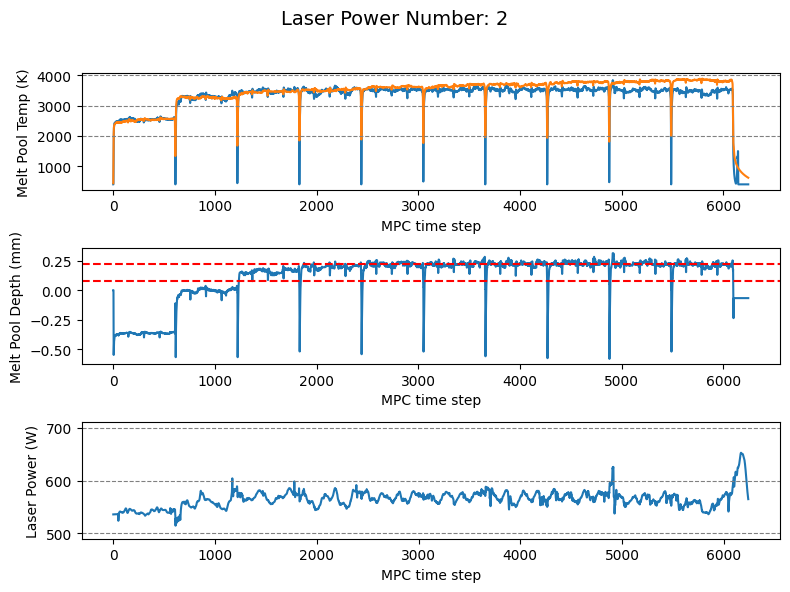

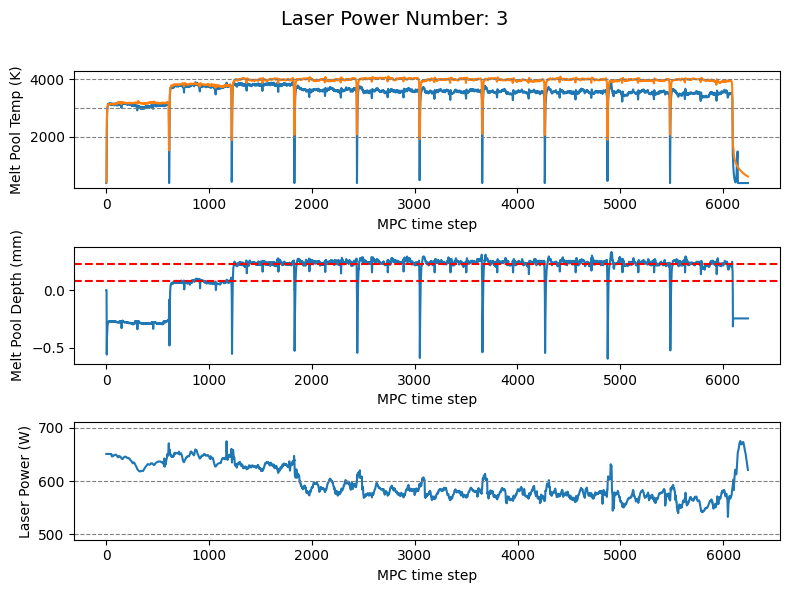

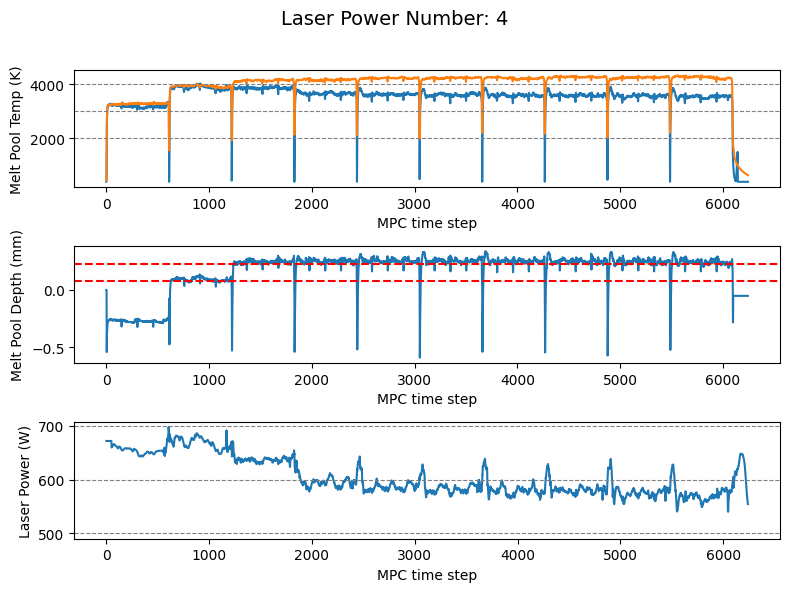

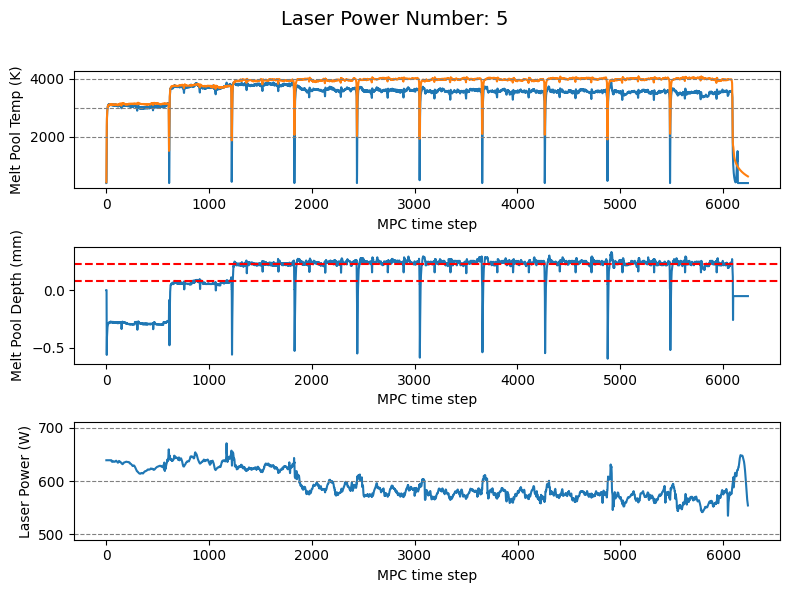

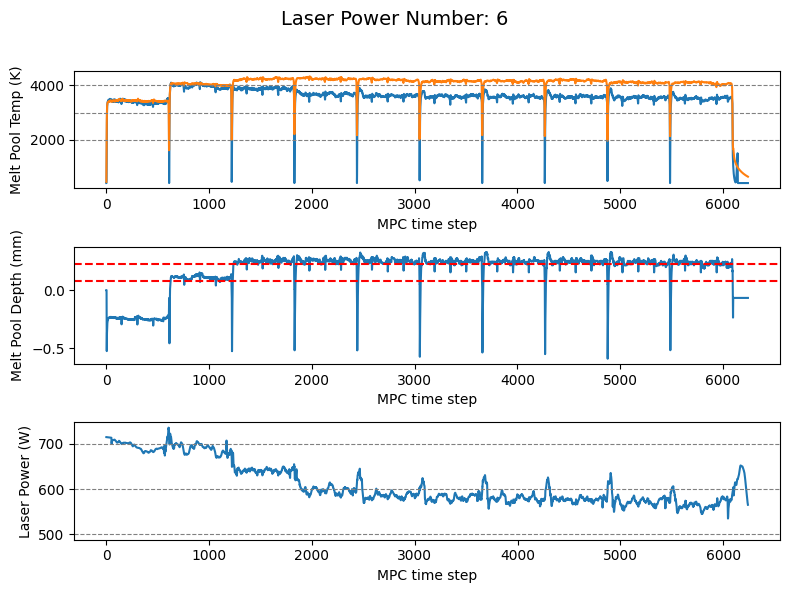

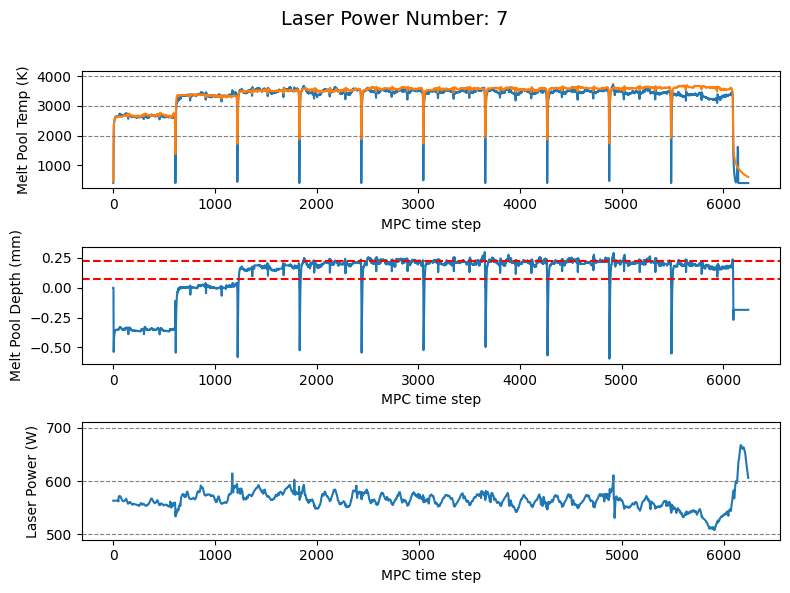

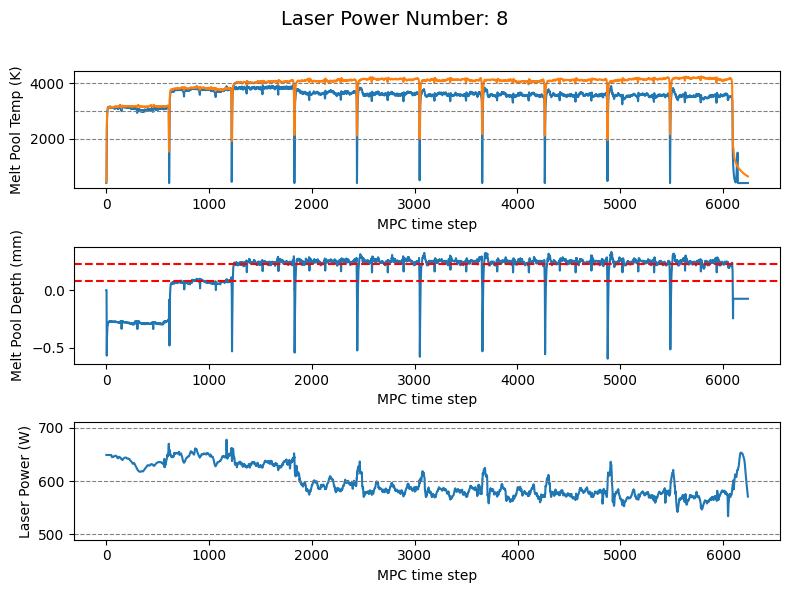

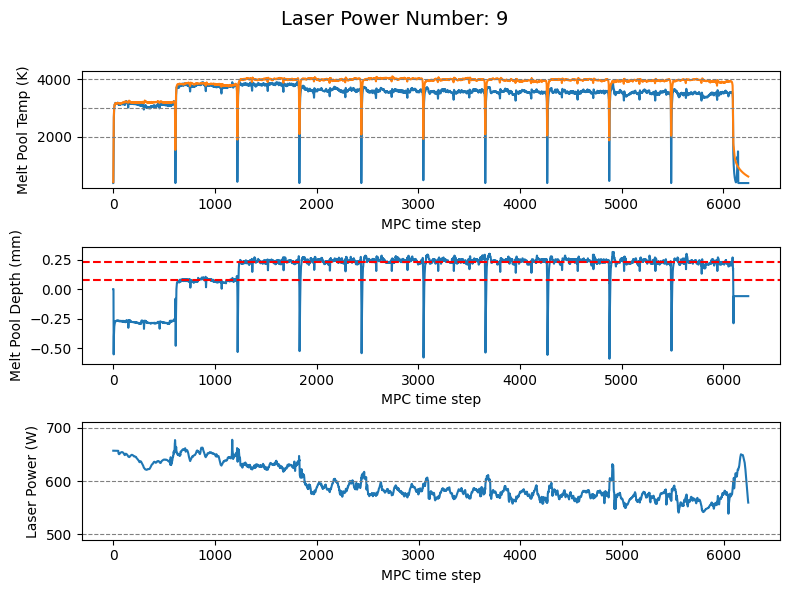

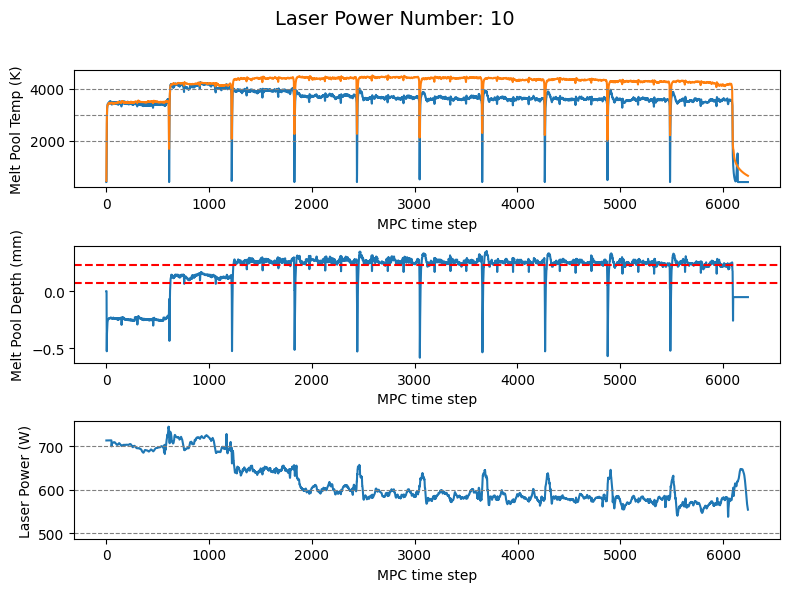

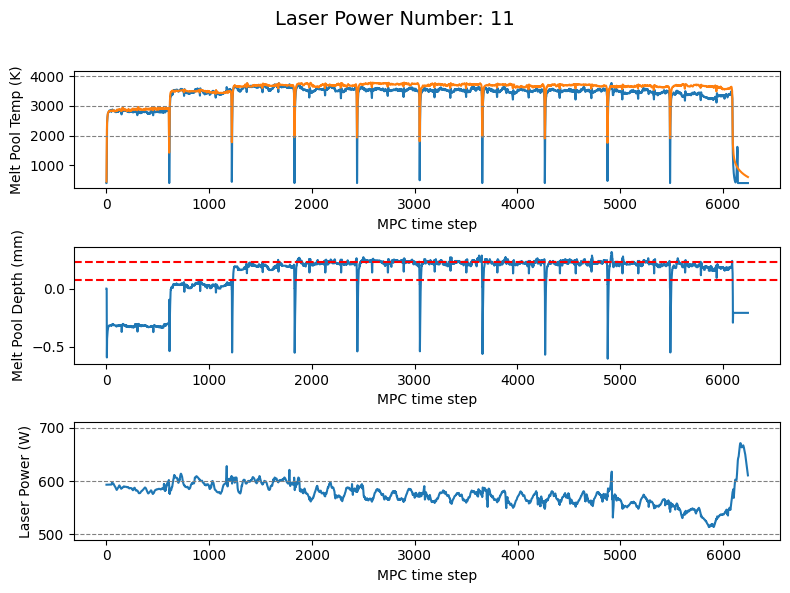

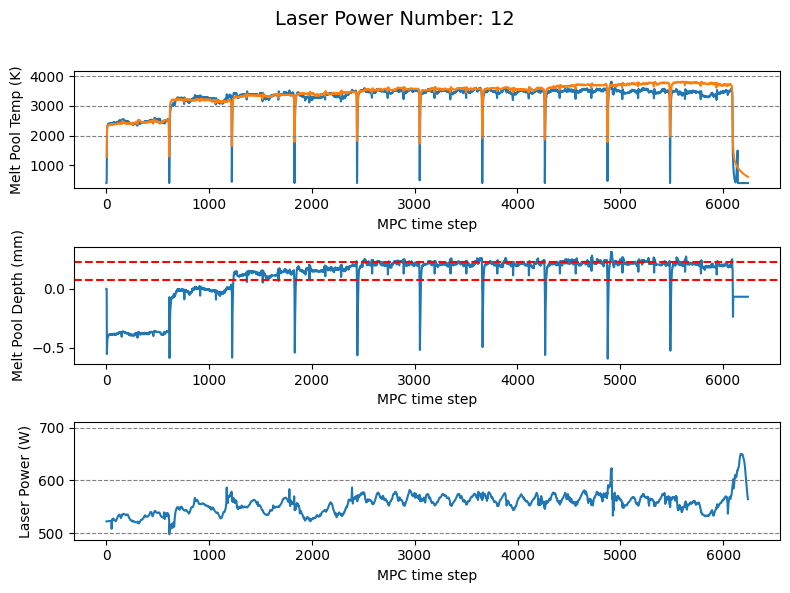

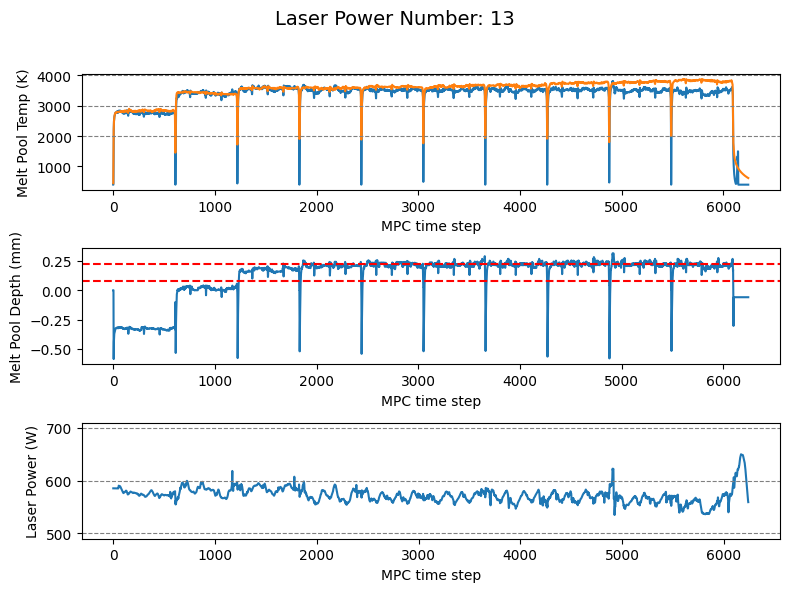

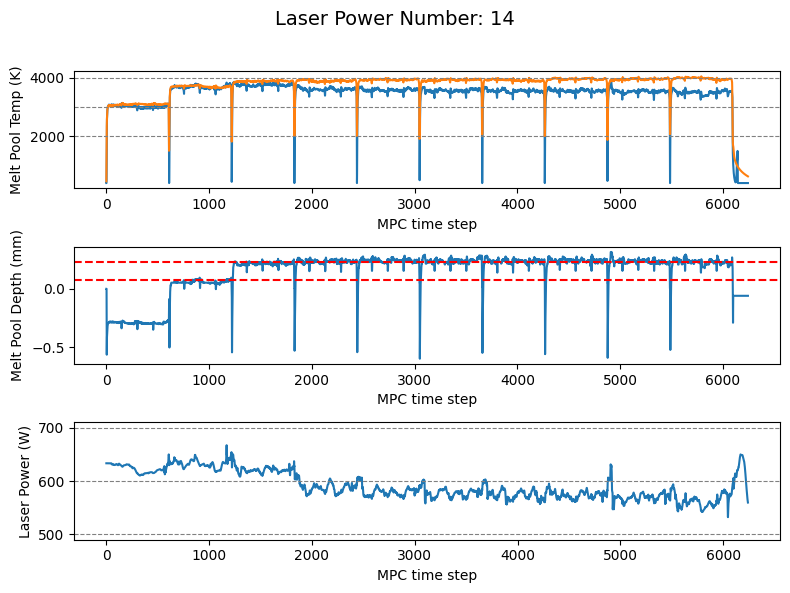

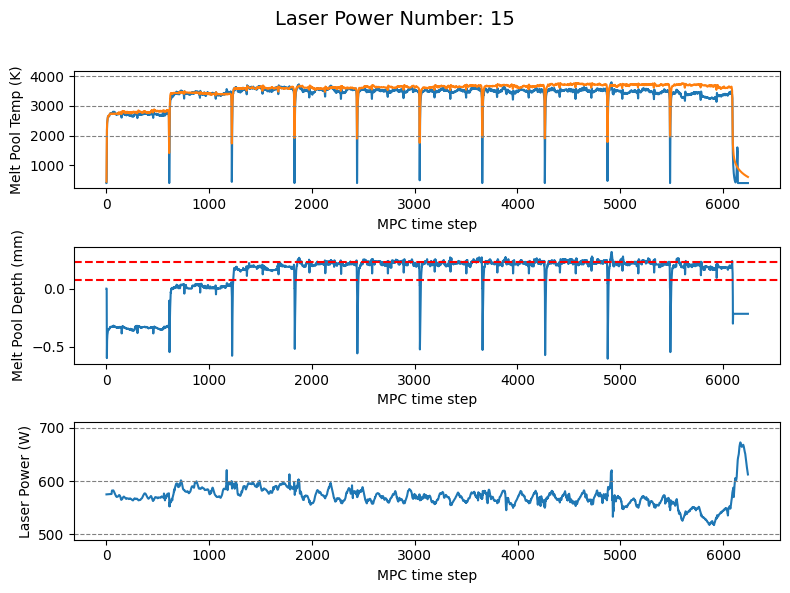

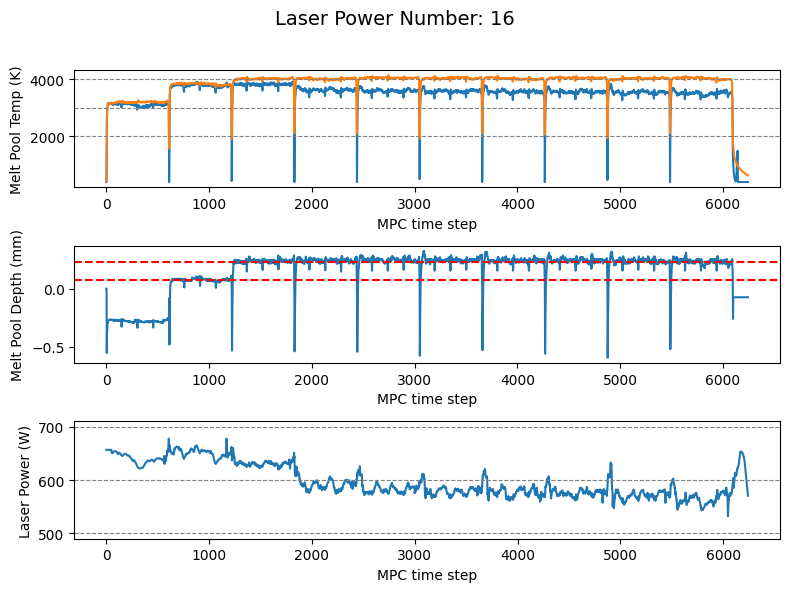

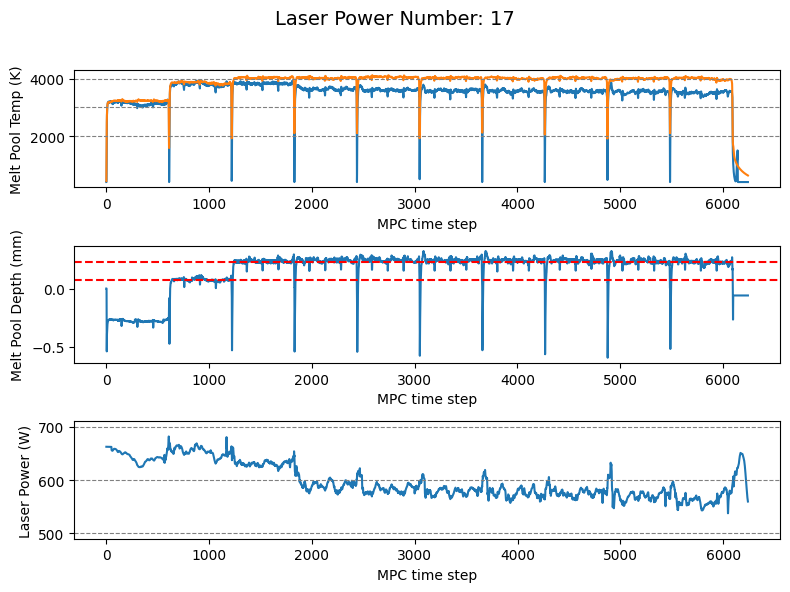

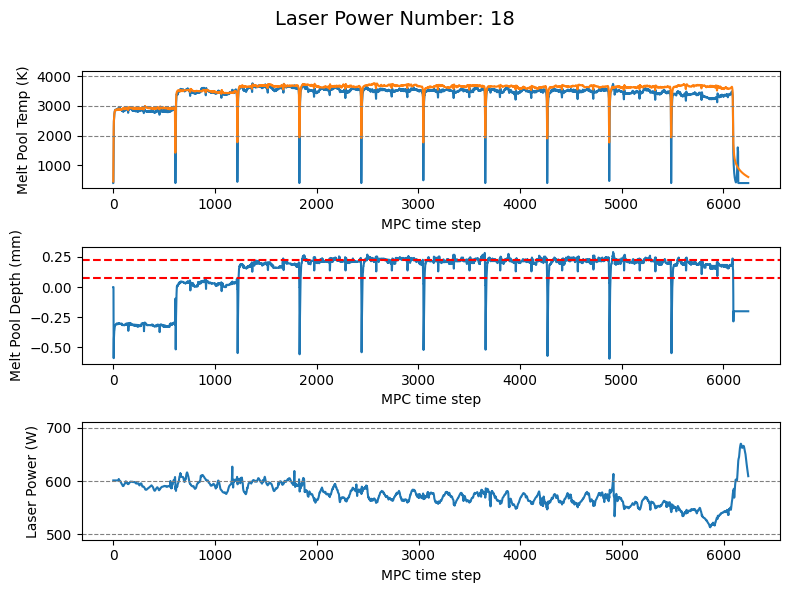

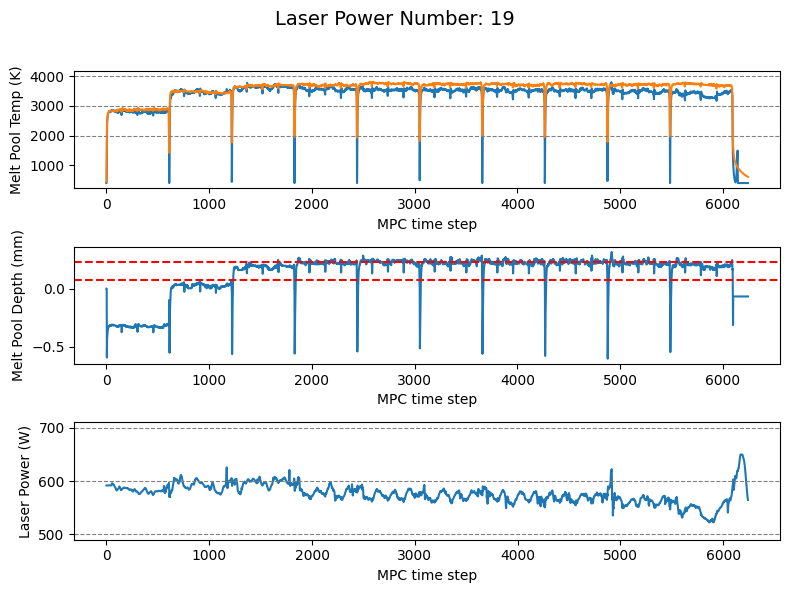

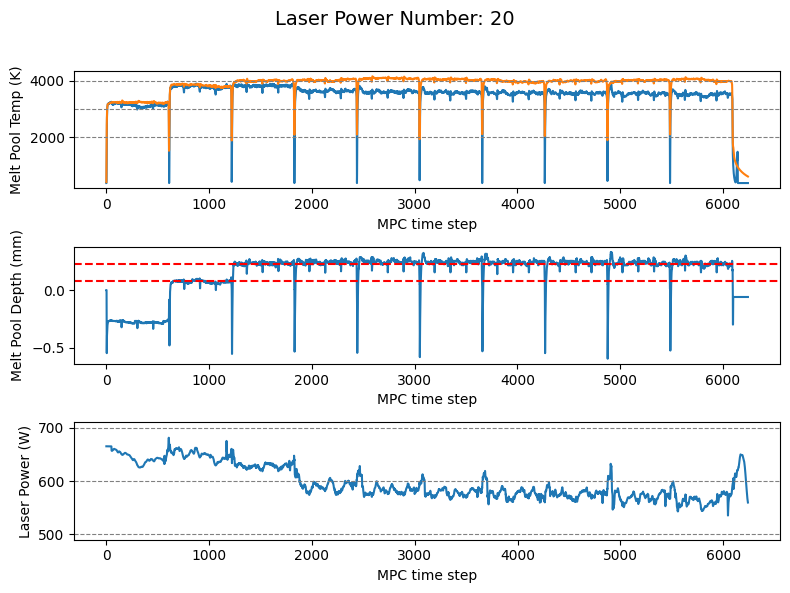

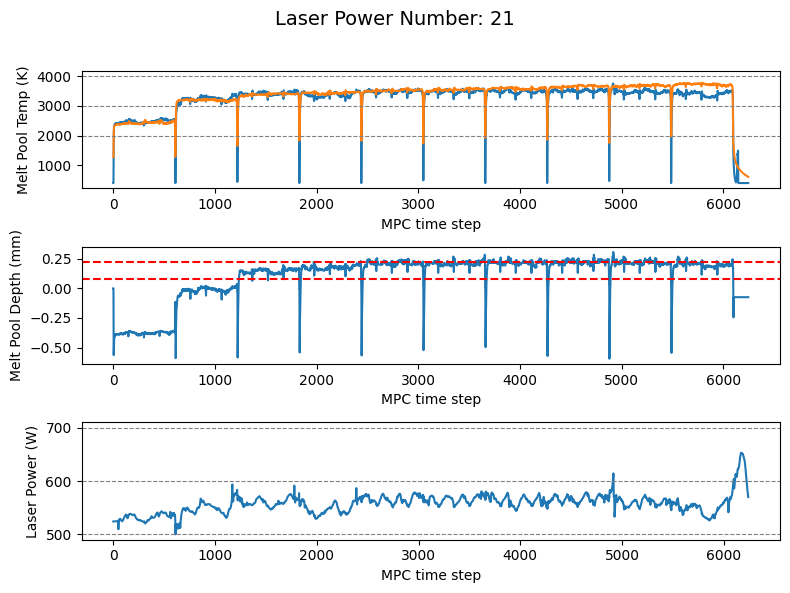

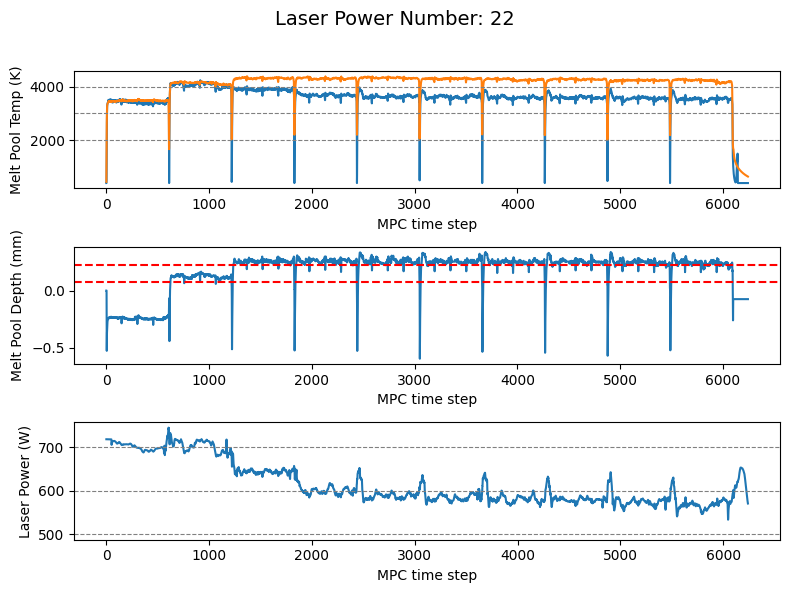

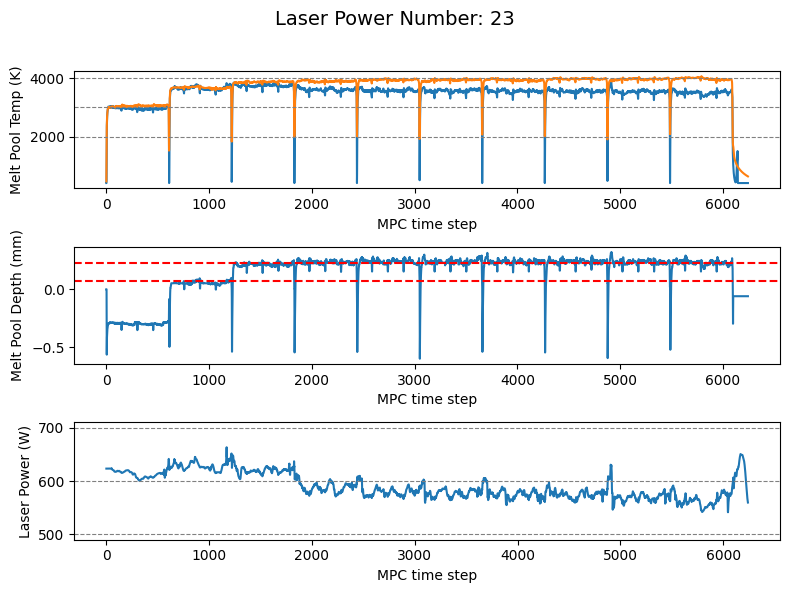

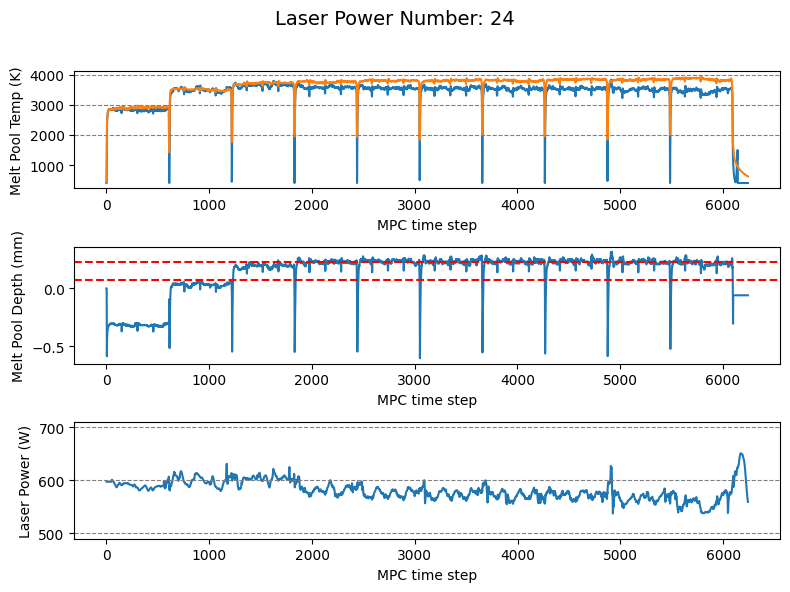

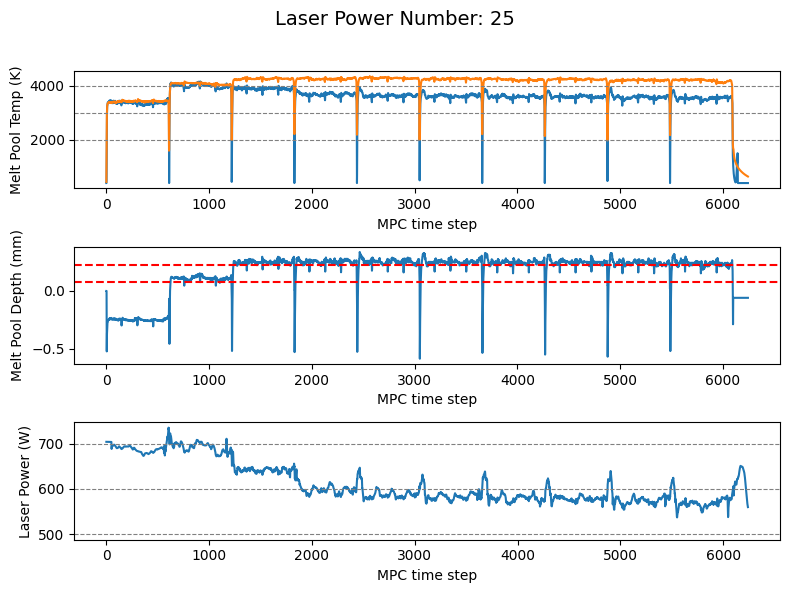

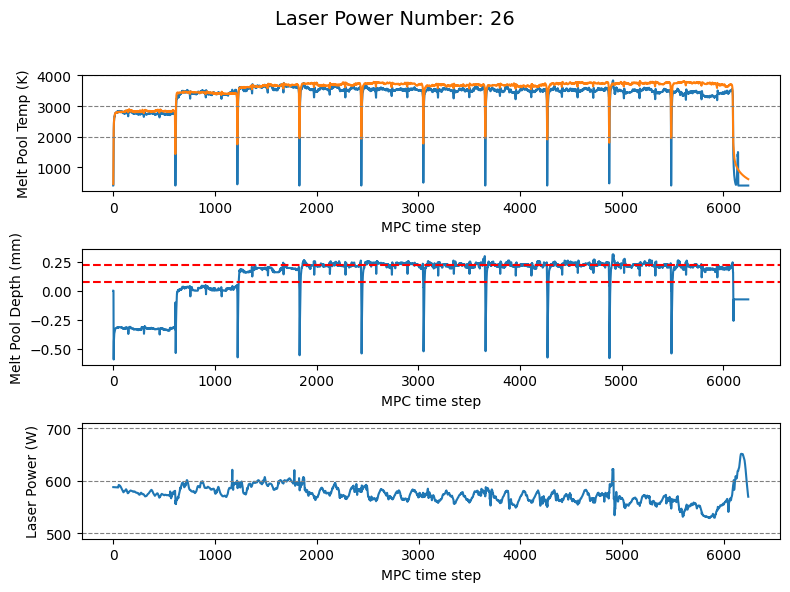

In [5]:
# ── Main Loop ───────────────────────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/5_policy_1223/simulation_outputs/simulation_outputs_B0"

# Find laser_power_numbers
all_files = os.listdir(save_dir)
laser_nums = sorted(set(
    int(re.search(r"(\d+)", f).group(1))
    for f in all_files if f.startswith("x_outputs_laser_")
))

print(f"📌 Found laser_power_numbers: {laser_nums}")

# Plot all
for laser_num in laser_nums:
    plot_saved_outputs(save_dir, laser_num)

# DPC_ro100_ep30_L3_H512_wt1.0_ws1.0_wc3.0_rollout0004

📌 Found laser_power_numbers: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


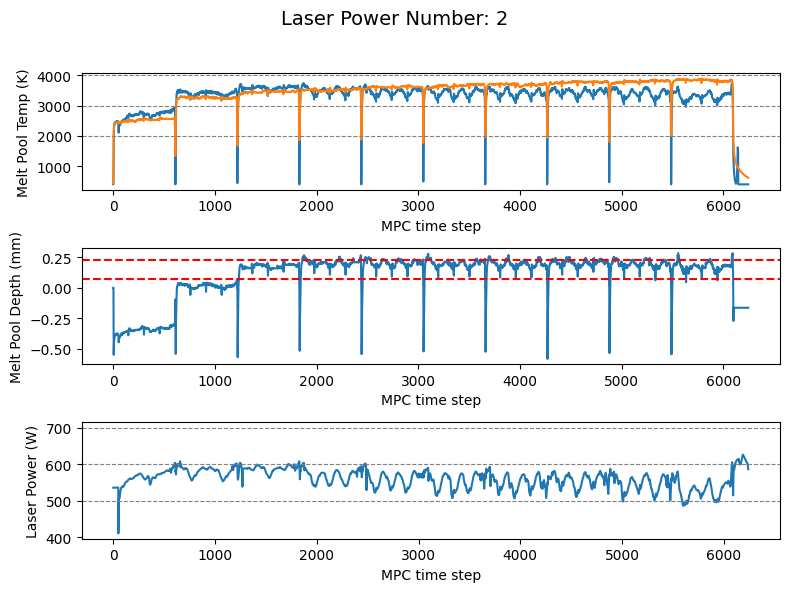

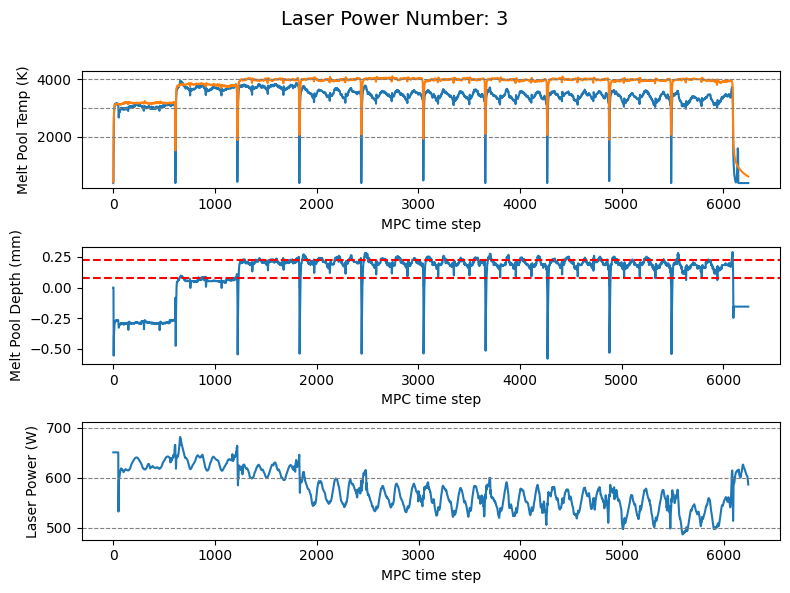

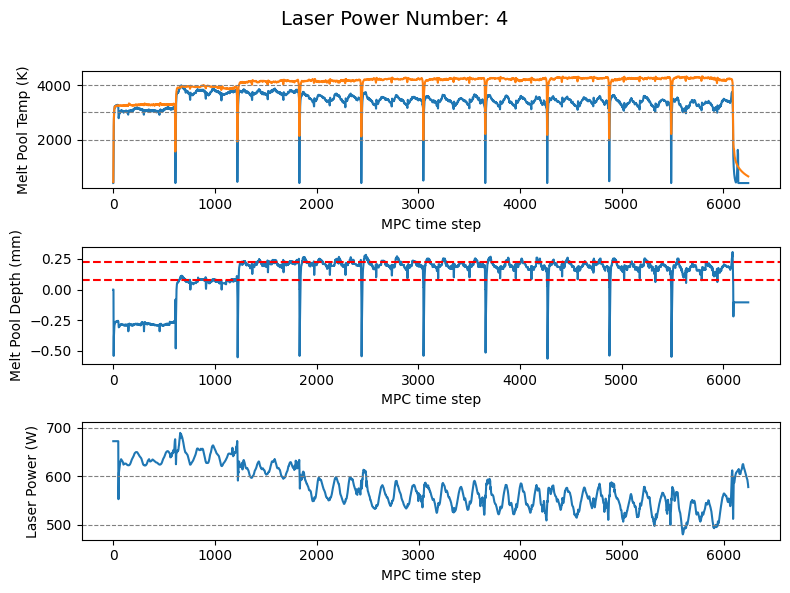

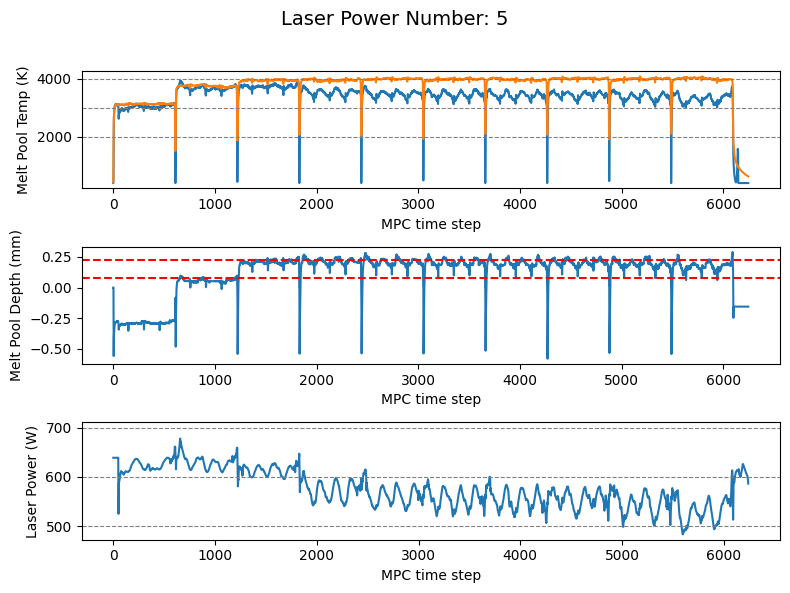

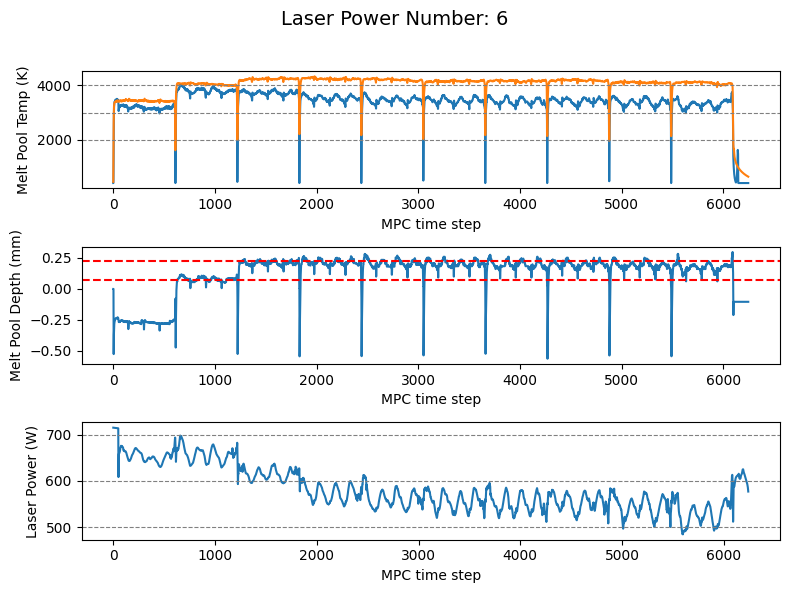

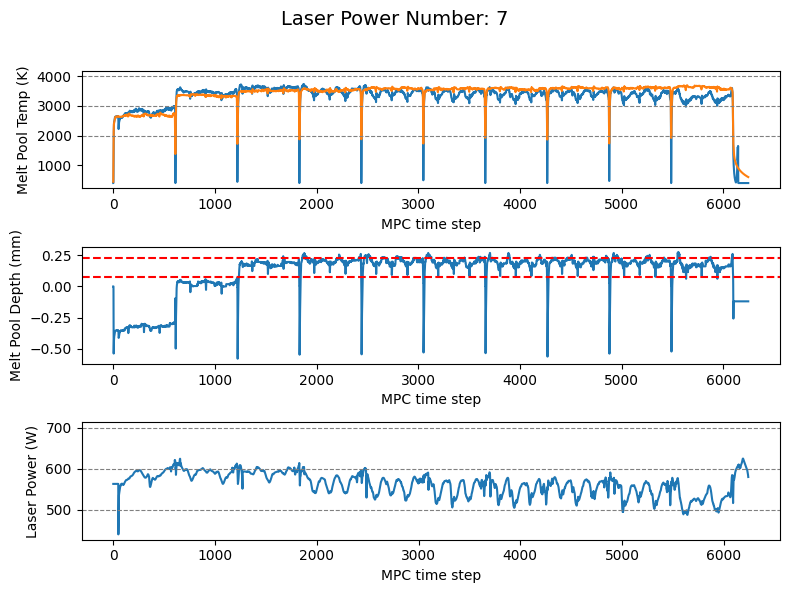

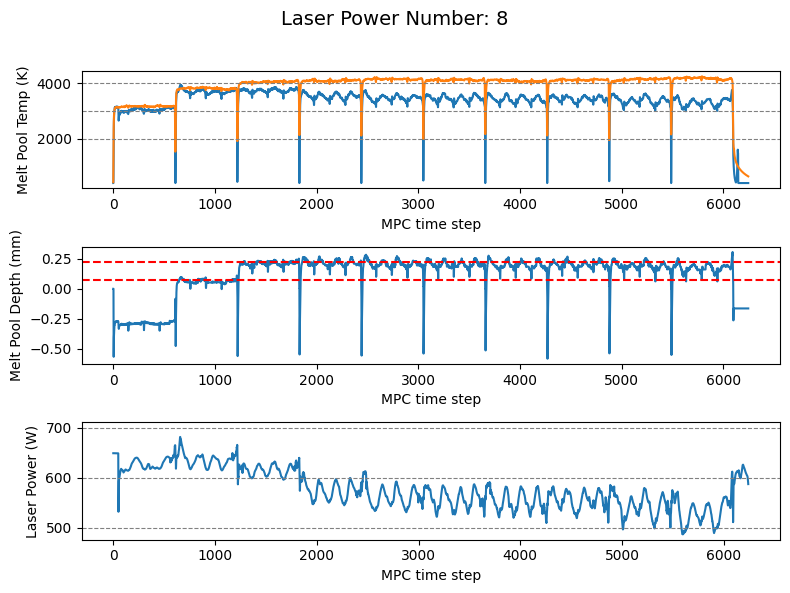

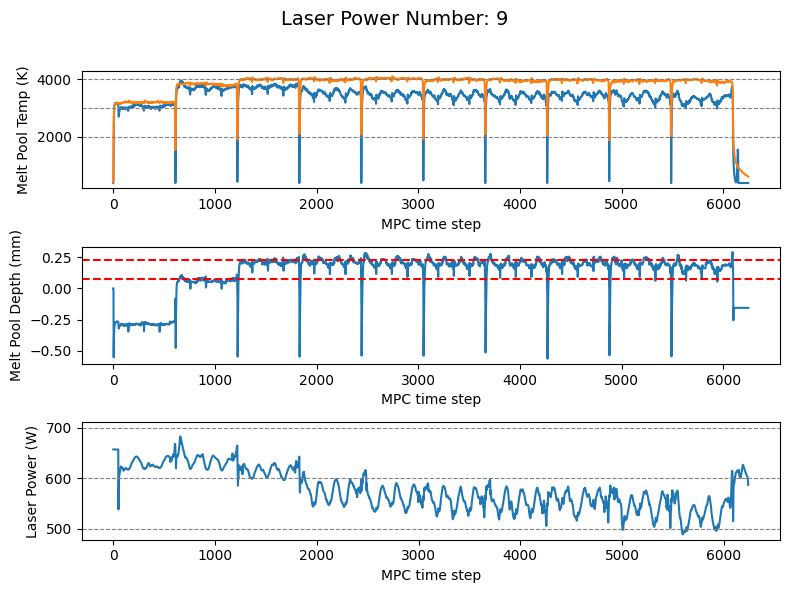

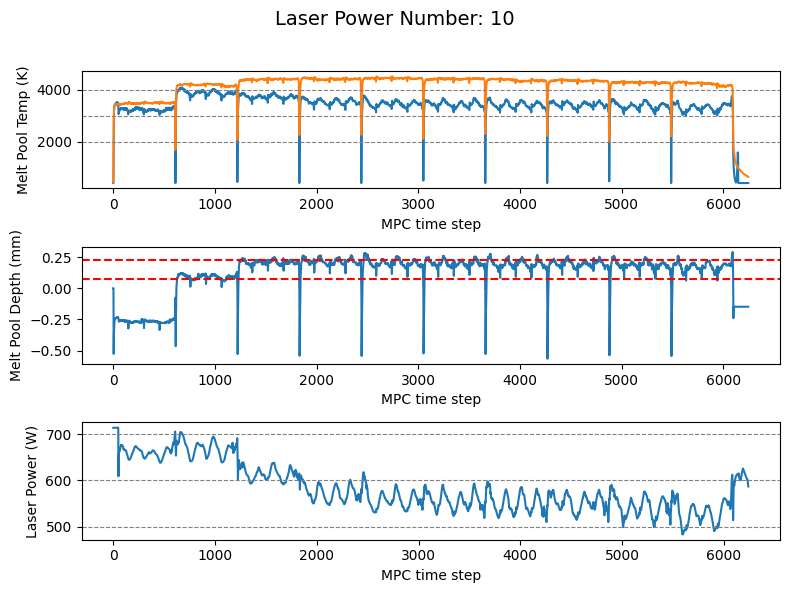

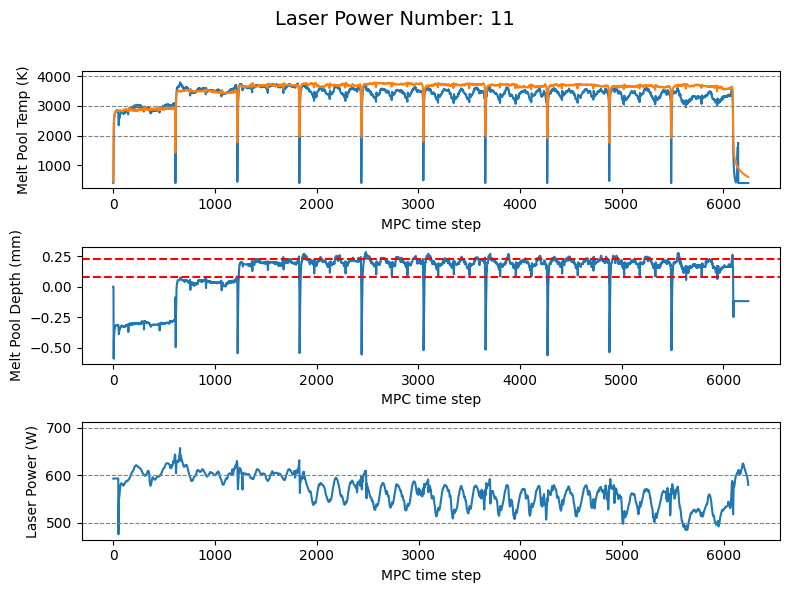

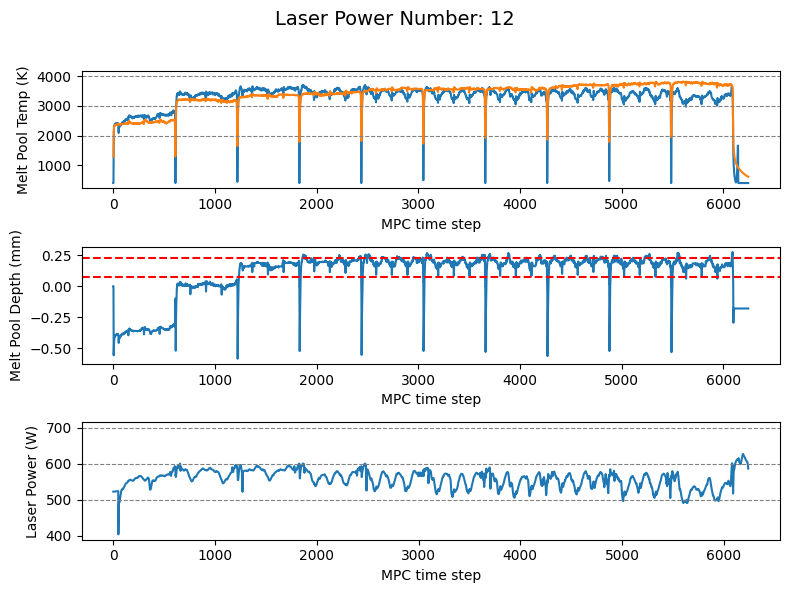

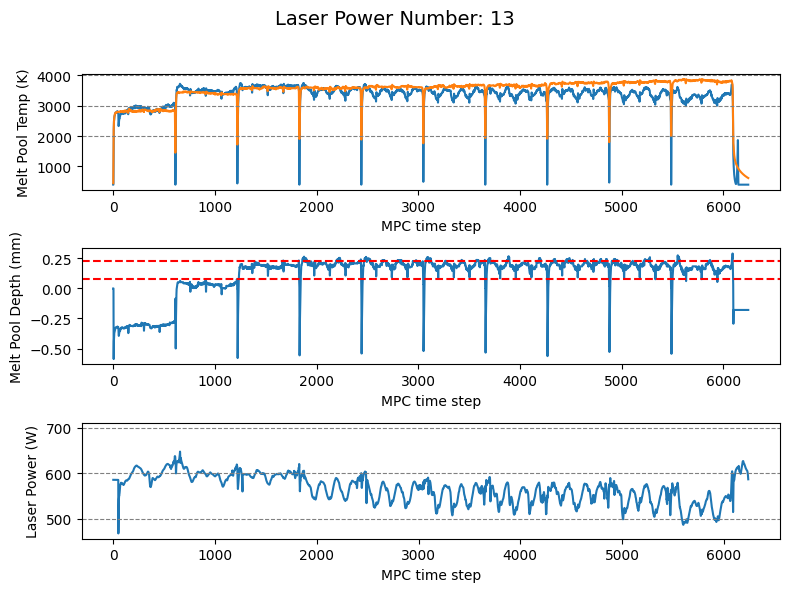

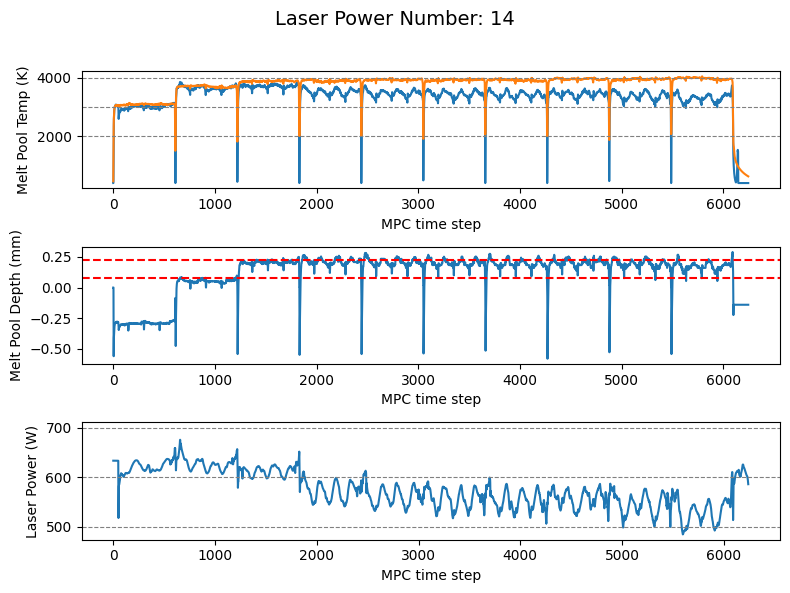

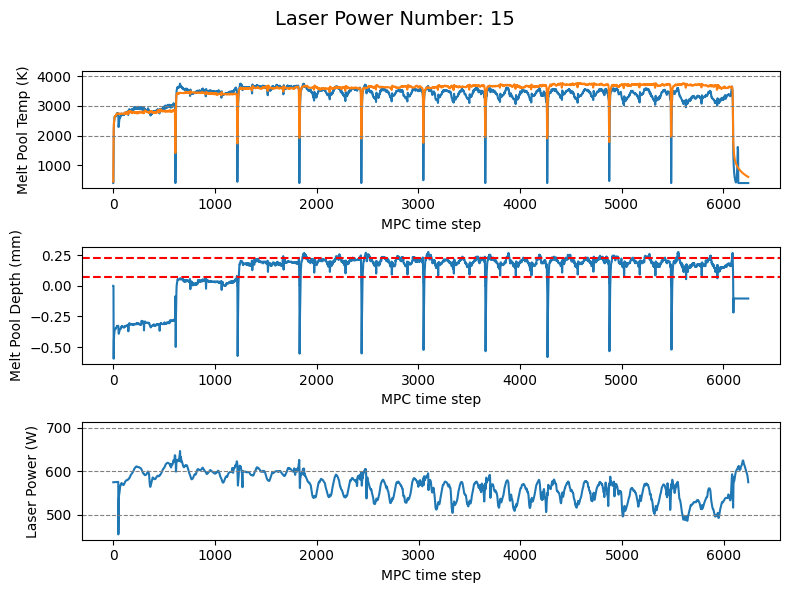

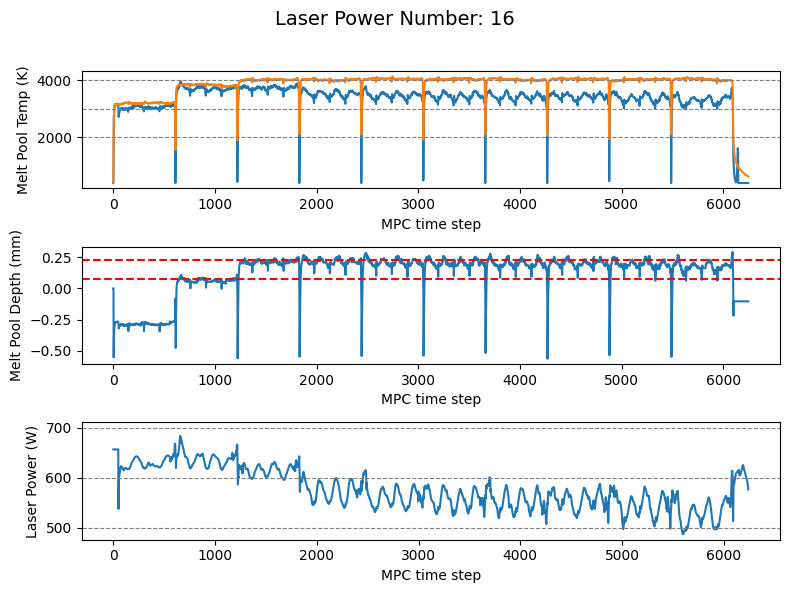

In [6]:
# ── Main Loop ───────────────────────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/5_policy_1223/simulation_outputs/simulation_outputs_0104_DPC_ro100_ep30_L3_H512_wt1.0_ws1.0_wc3.0_rollout0004" \
""

# Find laser_power_numbers
all_files = os.listdir(save_dir)
laser_nums = sorted(set(
    int(re.search(r"(\d+)", f).group(1))
    for f in all_files if f.startswith("x_outputs_laser_")
))

print(f"📌 Found laser_power_numbers: {laser_nums}")

# Plot all
for laser_num in laser_nums:
    plot_saved_outputs(save_dir, laser_num)

# DPC_ro100_ep10_L3_H512_wt1.0_ws3.0_wc1.0_rollout0005

📌 Found laser_power_numbers: [2, 3, 4]


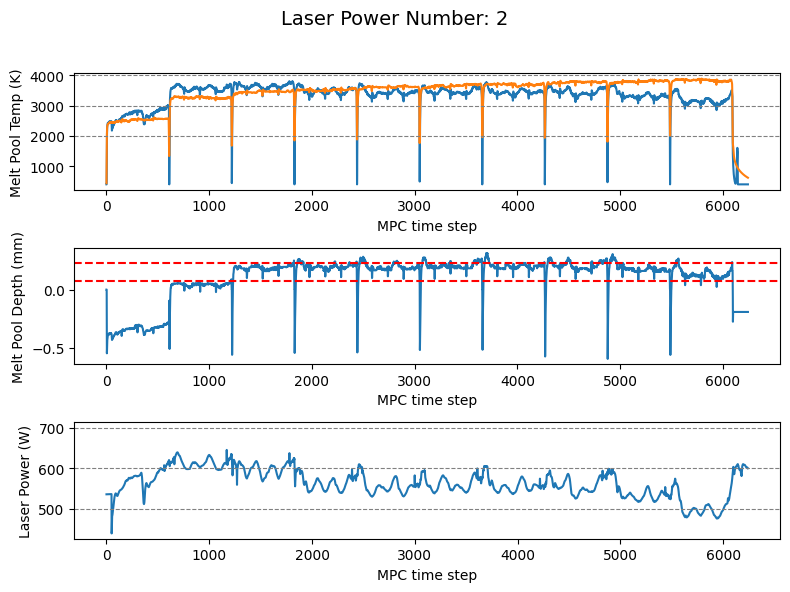

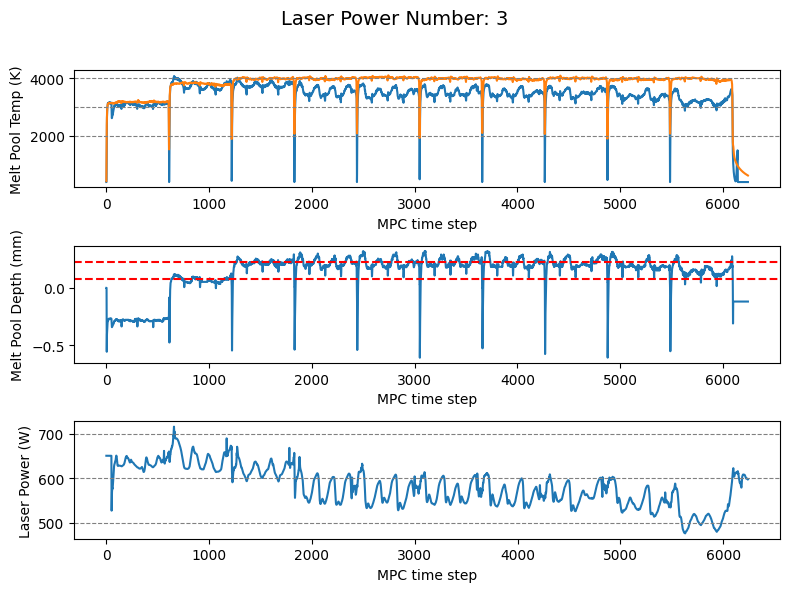

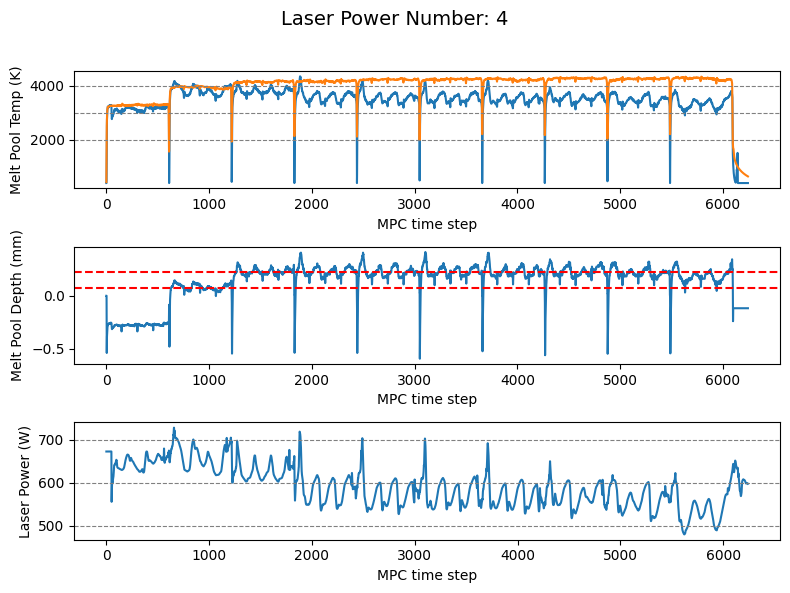

In [7]:
# ── Main Loop ───────────────────────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/5_policy_1223/simulation_outputs/simulation_outputs_0103_DPC_ro100_ep10_L3_H512_wt1.0_ws3.0_wc1.0_rollout0005" \
""

# Find laser_power_numbers
all_files = os.listdir(save_dir)
laser_nums = sorted(set(
    int(re.search(r"(\d+)", f).group(1))
    for f in all_files if f.startswith("x_outputs_laser_")
))

print(f"📌 Found laser_power_numbers: {laser_nums}")

# Plot all
for laser_num in laser_nums:
    plot_saved_outputs(save_dir, laser_num)

# DPC_policy_aug_1step_rollout0002_old

📌 Found laser_power_numbers: [2]


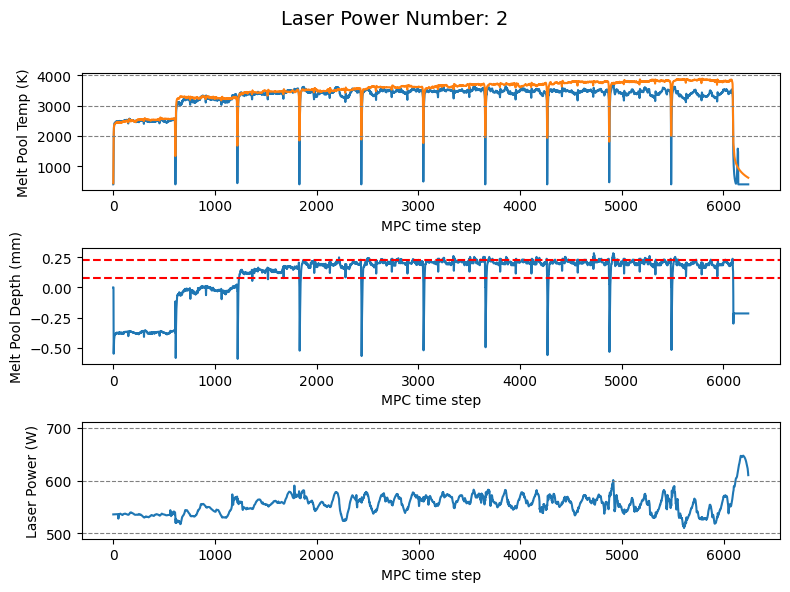

In [8]:
# ── Main Loop ───────────────────────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_rollout1_m256_epoch50/simulation/base"

# Find laser_power_numbers
all_files = os.listdir(save_dir)
laser_nums = sorted(set(
    int(re.search(r"(\d+)", f).group(1))
    for f in all_files if f.startswith("x_outputs_laser_")
))

print(f"📌 Found laser_power_numbers: {laser_nums}")

# Plot all
for laser_num in laser_nums:
    plot_saved_outputs(save_dir, laser_num)

📌 Found laser_power_numbers: [2, 3, 4, 5]


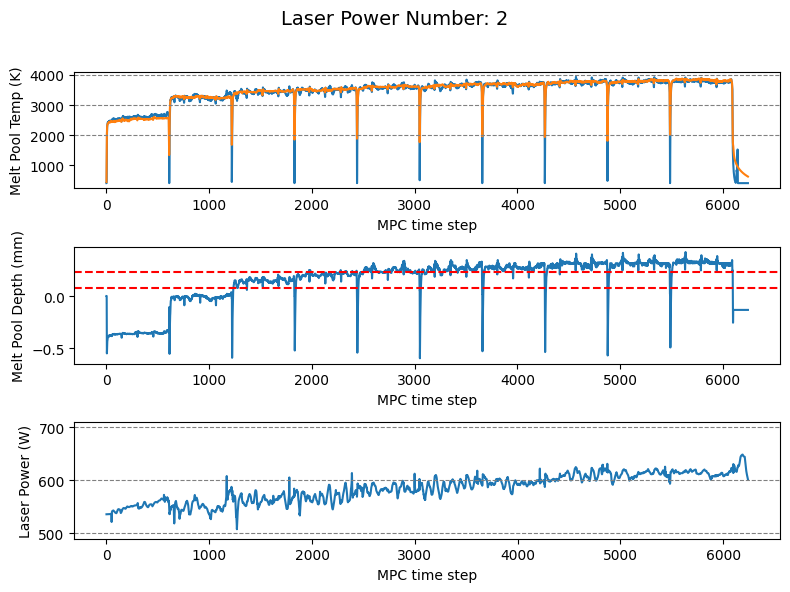

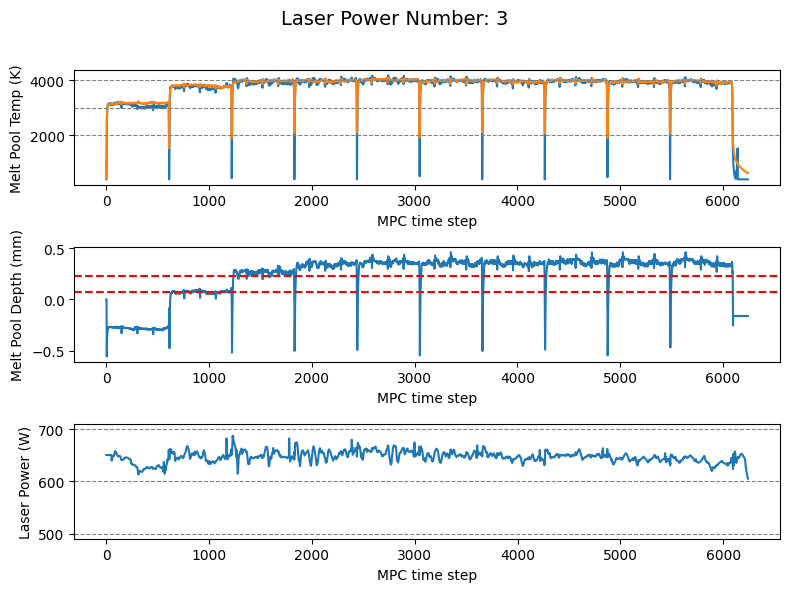

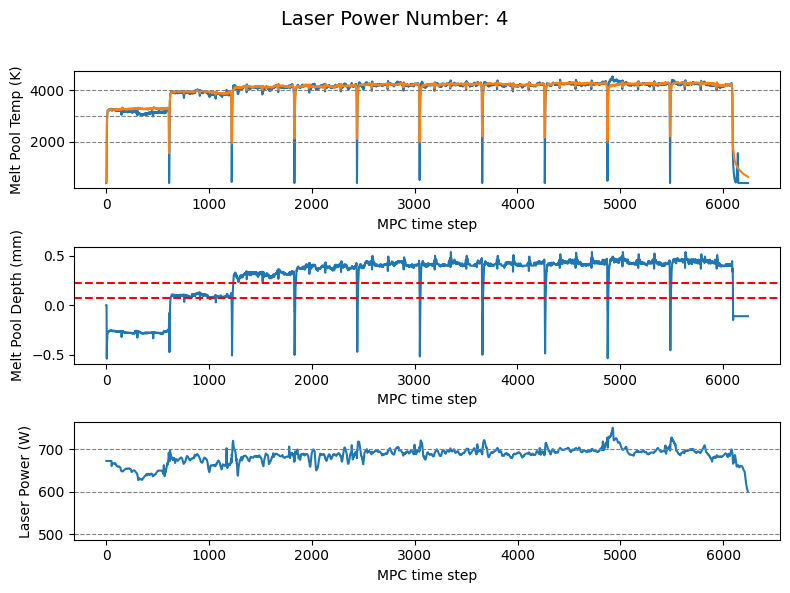

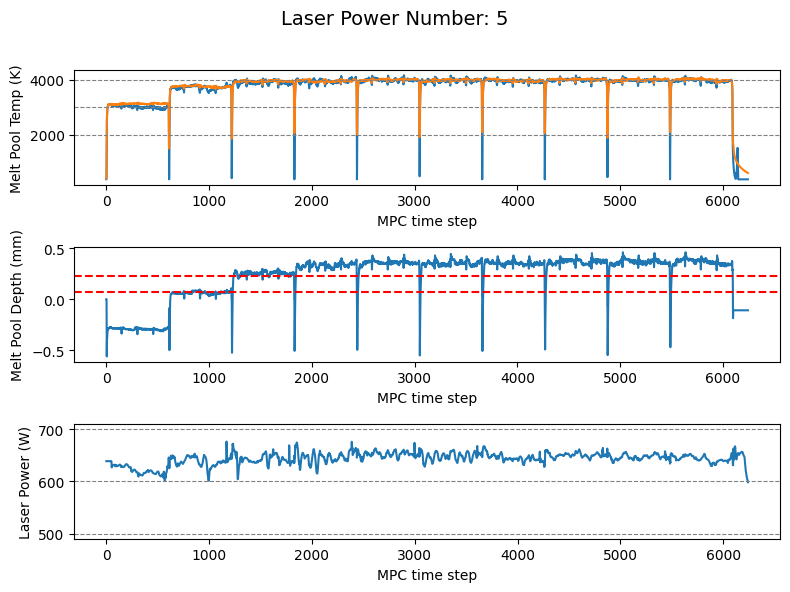

In [9]:
# ── Main Loop ───────────────────────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline/simulation/policy_model_3L_1024H_s1_c0"

# Find laser_power_numbers
all_files = os.listdir(save_dir)
laser_nums = sorted(set(
    int(re.search(r"(\d+)", f).group(1))
    for f in all_files if f.startswith("x_outputs_laser_")
))

print(f"📌 Found laser_power_numbers: {laser_nums}")

# Plot all
for laser_num in laser_nums:
    plot_saved_outputs(save_dir, laser_num)

📌 Found laser_power_numbers: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


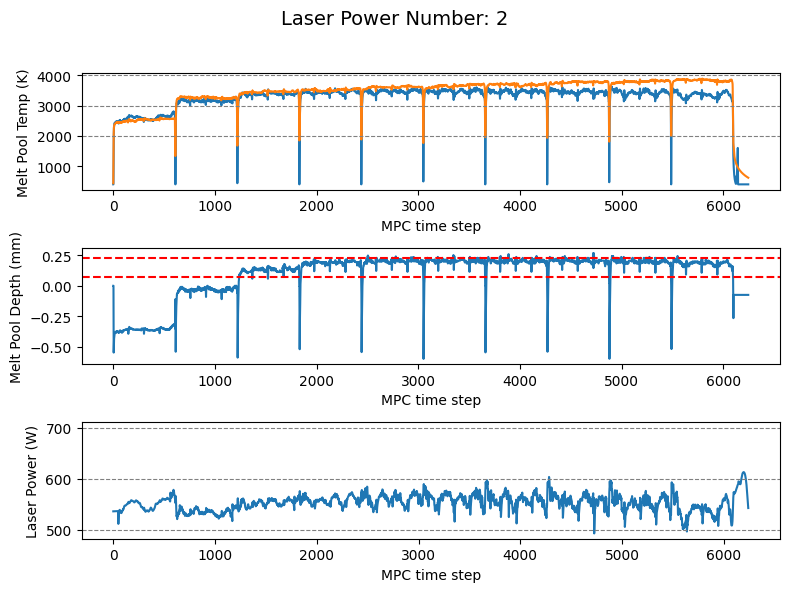

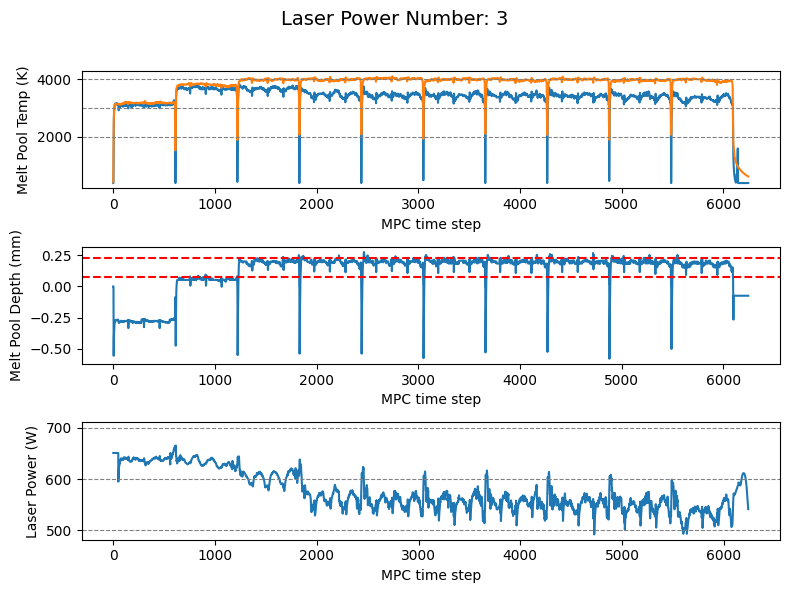

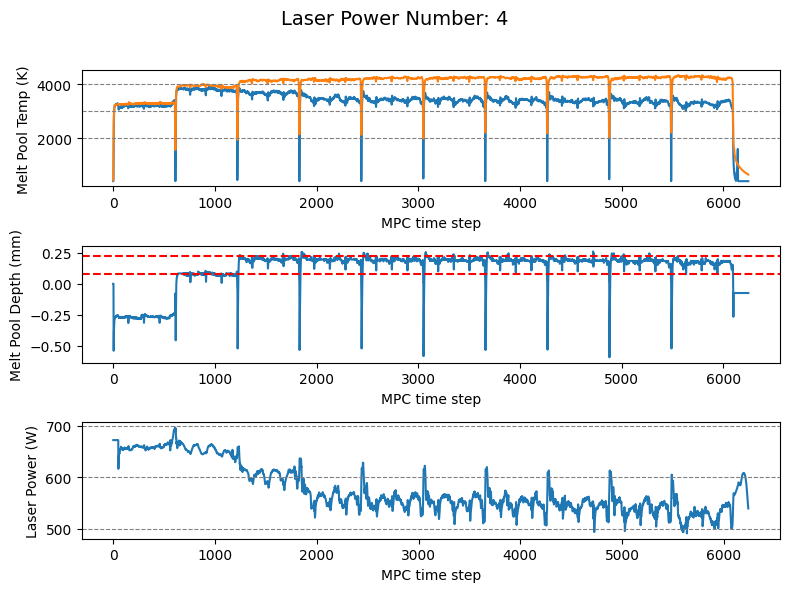

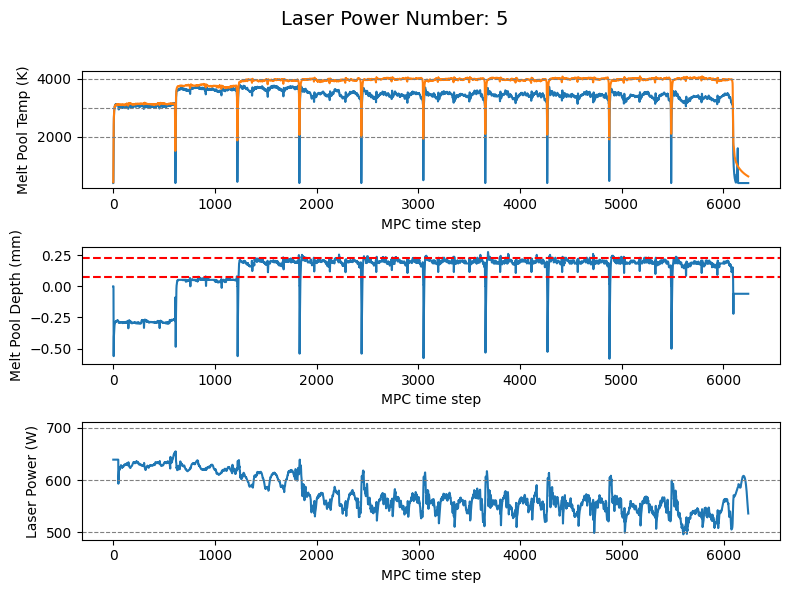

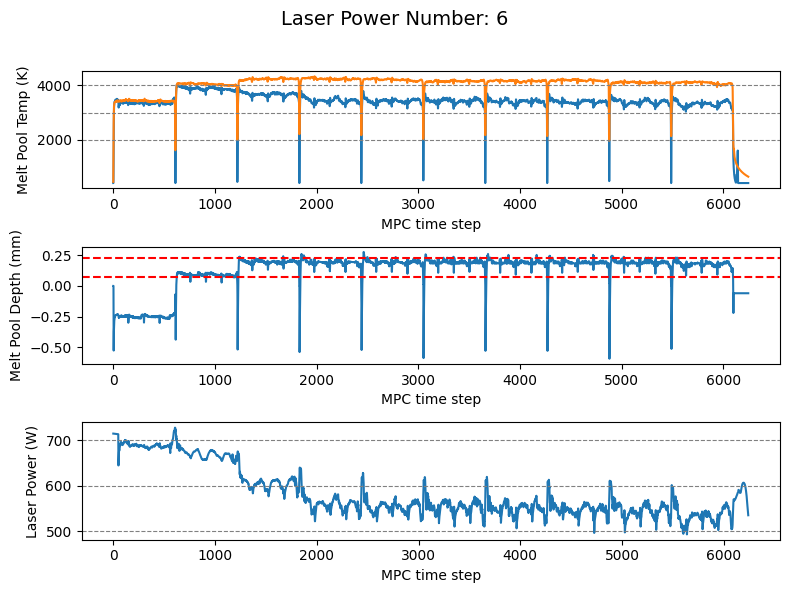

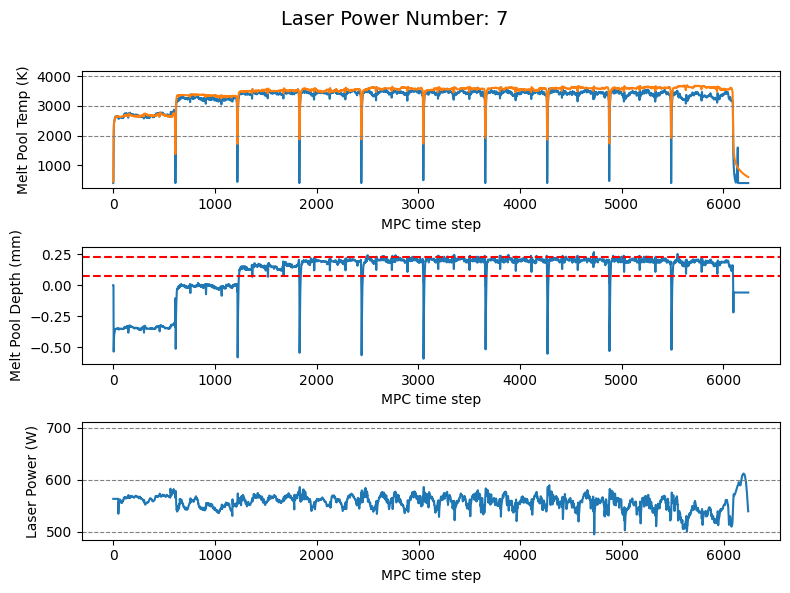

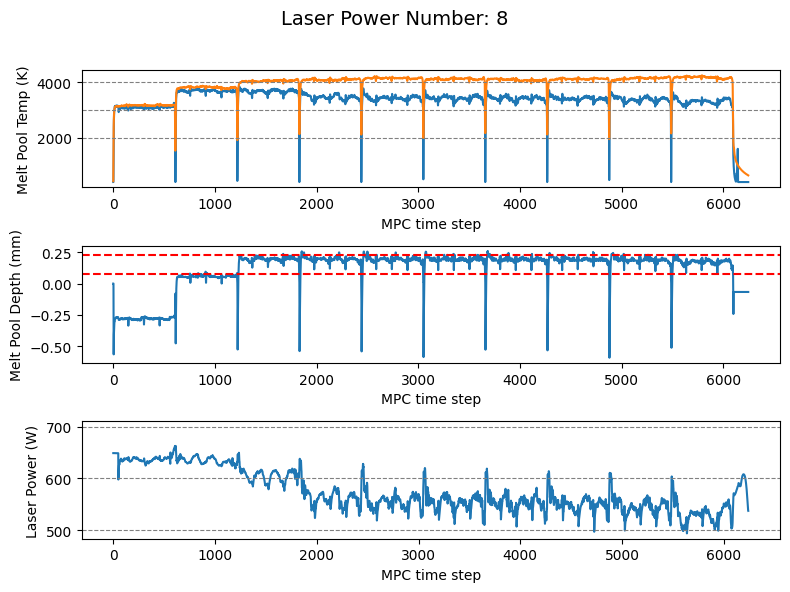

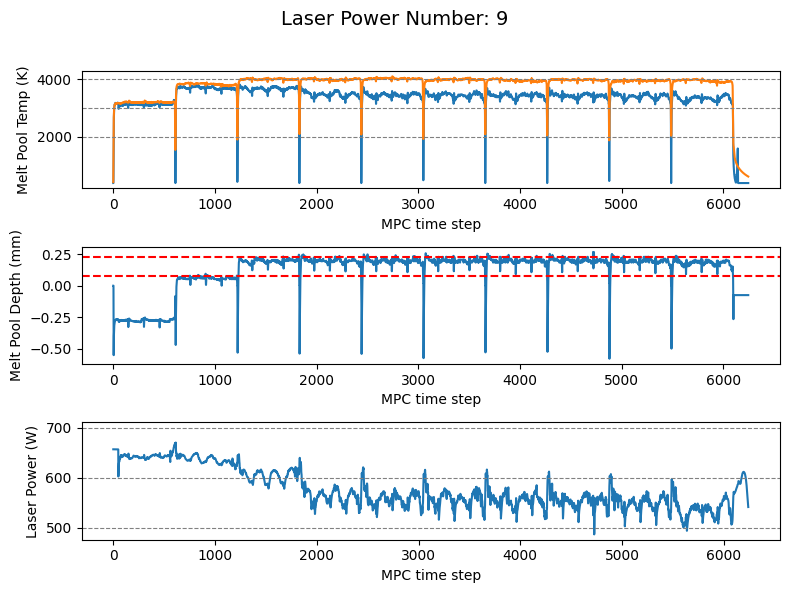

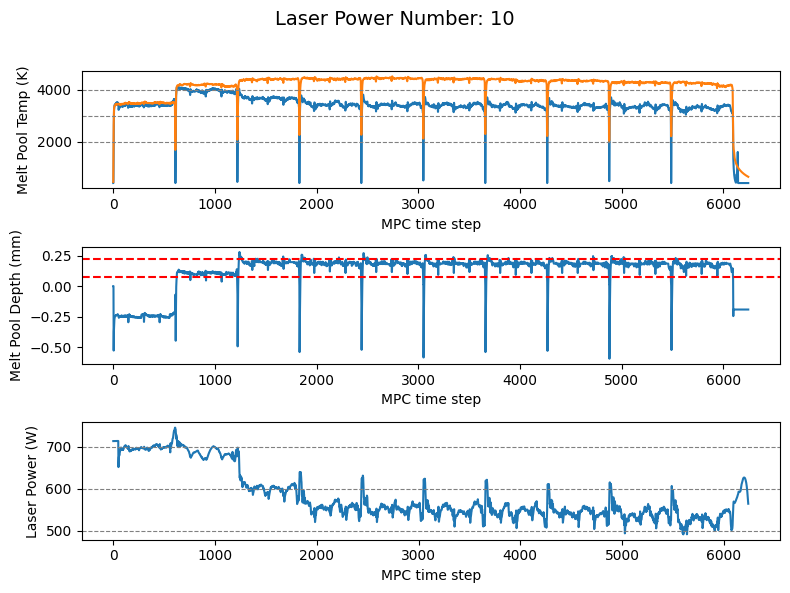

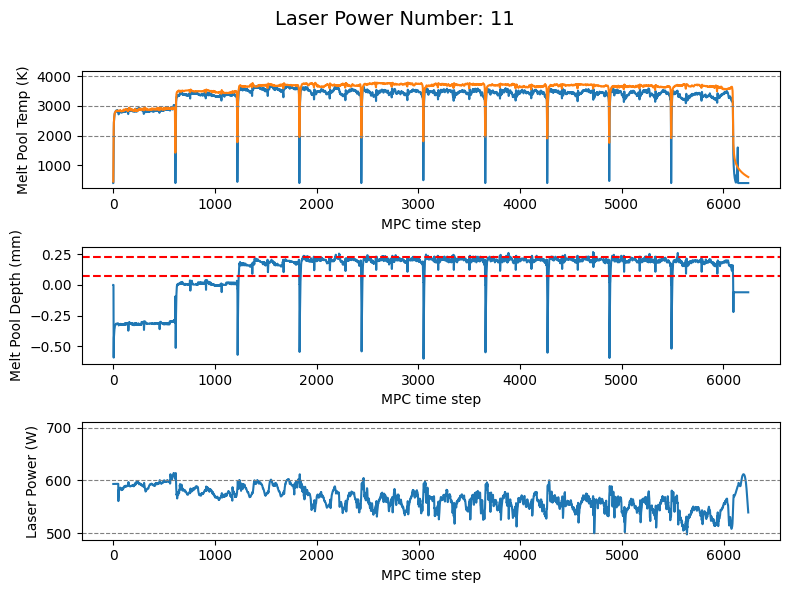

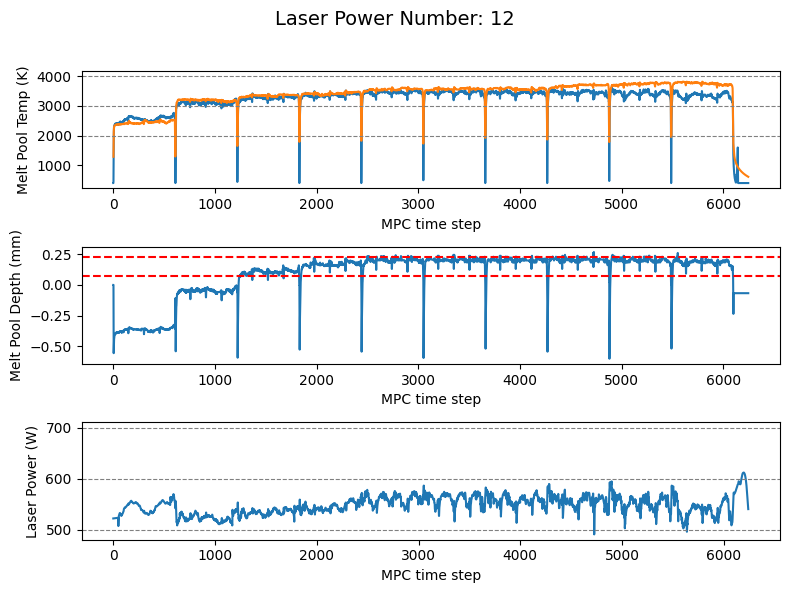

In [10]:
# ── Main Loop ───────────────────────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_shift/3L_1024H_s1_c3_ep20_roll10_m1024_base/simulation"

# Find laser_power_numbers
all_files = os.listdir(save_dir)
laser_nums = sorted(set(
    int(re.search(r"(\d+)", f).group(1))
    for f in all_files if f.startswith("x_outputs_laser_")
))

print(f"📌 Found laser_power_numbers: {laser_nums}")

# Plot all
for laser_num in laser_nums:
    plot_saved_outputs(save_dir, laser_num)